In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
import kagglehub
path = kagglehub.dataset_download("rakeshrau/social-network-ads")

Using Colab cache for faster access to the 'social-network-ads' dataset.


In [36]:
df = pd.read_csv(path + "/Social_Network_Ads.csv")

In [56]:
x = df.iloc[:,2:4]

In [57]:
y = df['Purchased']

In [58]:
x

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [48]:
import seaborn as sns

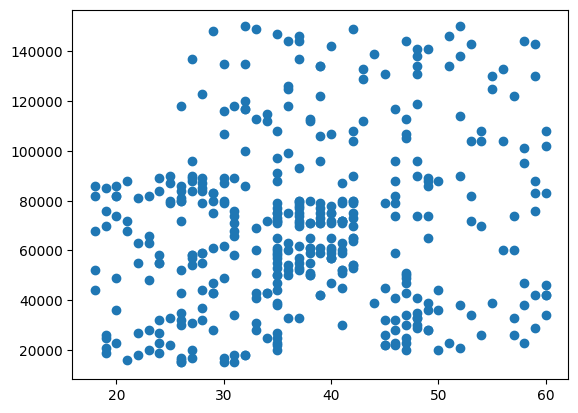

In [62]:
plt.figure()
plt.scatter(x['Age'],x['EstimatedSalary'])
plt.show()

In [65]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [68]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(2,)),
    Dense(32, activation='relu'),
    Dense(1, activation ='linear')
])

In [69]:
model.compile(loss='binary_crossentropy', metrics = ['accuracy'], optimizer = 'adam')

In [75]:
callback = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.1,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [70]:
from sklearn.model_selection import train_test_split

In [82]:
x_train,x_test,y_train,y_test = train_test_split(x , y, random_state = 42)

In [86]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
x_train_scaled = ss.fit_transform(x_train)
x_test_scaled = ss.fit_transform(x_test)

In [92]:
history = model.fit(x_train,y_train, epochs = 100, validation_data = (x_test,y_test), verbose = 1)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3533 - loss: 10.3094 - val_accuracy: 0.3700 - val_loss: 10.0437
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3533 - loss: 10.3094 - val_accuracy: 0.3700 - val_loss: 10.0437
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3533 - loss: 10.3094 - val_accuracy: 0.3700 - val_loss: 10.0437
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3533 - loss: 10.3094 - val_accuracy: 0.3700 - val_loss: 10.0437
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3533 - loss: 10.3094 - val_accuracy: 0.3700 - val_loss: 10.0437
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3533 - loss: 10.3094 - val_accuracy: 0.3700 - val_loss: 10.0437
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3533 - loss: 10.3094 - val_accuracy: 0.3700 - val_loss: 10.0437
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3533 - loss: 10.3094 - v

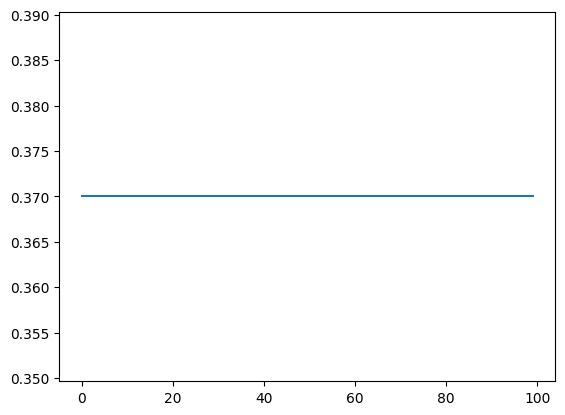

In [93]:
plt.plot(history.history['val_accuracy'])

In [94]:
history1 = model.fit(x_train_scaled,y_train, epochs = 100, validation_data = (x_test_scaled,y_test), verbose = 1)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9067 - loss: 0.4504 - val_accuracy: 0.9200 - val_loss: 0.3160
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9133 - loss: 0.4464 - val_accuracy: 0.9300 - val_loss: 0.2091
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9100 - loss: 0.4441 - val_accuracy: 0.9200 - val_loss: 0.1757
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9033 - loss: 0.4432 - val_accuracy: 0.9200 - val_loss: 0.1847
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9100 - loss: 0.4401 - val_accuracy: 0.9400 - val_loss: 0.1834
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9133 - loss: 0.4381 - val_accuracy: 0.9300 - val_loss: 0.1795
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9067 - loss: 0.4372 - val_accuracy: 0.9300 - val_loss: 0.1929
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9133 - loss: 0.4366 - val_accuracy: 0.

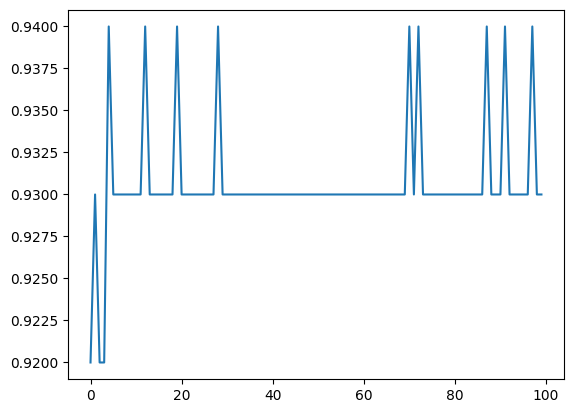

In [95]:
plt.plot(history1.history['val_accuracy'])